# Center blob input: open vs toroidal boundaries

Fixed input blob at the center of the grid that **disappears at the halfway point**. We run the same input with **closed (open)** and **toroidal** boundary conditions, then generate and display GIFs saved in the **Examples** folder.

In [63]:
import pathlib
import sys

root = pathlib.Path.cwd()
if (root / "wta2d").exists() and str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt
import wta2d
from wta2d import viz
from wta2d.inputs import pattern_input
from wta2d.grid import grid_positions

In [64]:
# Build a fixed center blob: 1 in a small disk at center, 0 elsewhere. Turns off at 50% of time.
side = 40
tlen = 5000
blob_radius = 2  # grid units from center (1-based)
scale = 1.0
turn_off_frac = 0.25

N, pos, _ = wta2d.make_grid(side)
center = (side + 1) / 2.0
dist_from_center = np.sqrt((pos[:, 0] - center) ** 2 + (pos[:, 1] - center) ** 2)
blob = np.zeros(N)
blob[dist_from_center <= blob_radius] = scale

#Inp = 0.25*pattern_input(tlen, blob, scale=1.0, turn_off_after_frac=turn_off_frac) + wta2d.random_sparse_input(tlen, N, sparsity=0.55, scale=1.0)
Inp = wta2d.random_sparse_input(tlen, N, sparsity=0.55, scale=1.0)

In [65]:
# We / Wi kernel parameters — shared by both open and toroidal simulations (tweak here)
Ae = 0.7    # excitatory kernel height
ke = 1.5    # excitatory kernel width
Ai = 0.05 # inhibitory kernel height
ki = 3.50    # inhibitory kernel width

In [66]:
# Run with closed (open) and toroidal boundary conditions (same We/Wi params)
xs_open, Inp_open, We_open, Wi_open, aa_open = wta2d.run(
    side=side,
    tlen=tlen,
    Inp=Inp,
    boundary="open",
    Ae=Ae, ke=ke, Ai=Ai, ki=ki,
)

xs_toroidal, Inp_toroidal, We_toroidal, Wi_toroidal, aa_toroidal = wta2d.run(
    side=side,
    tlen=tlen,
    Inp=Inp,
    boundary="toroidal",
    Ae=Ae, ke=ke, Ai=Ai, ki=ki,
)

Saved Examples/center_blob_open.gif and Examples/center_blob_toroidal.gif


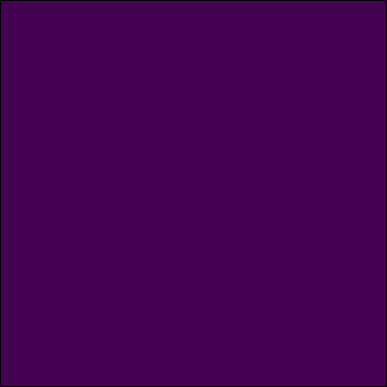

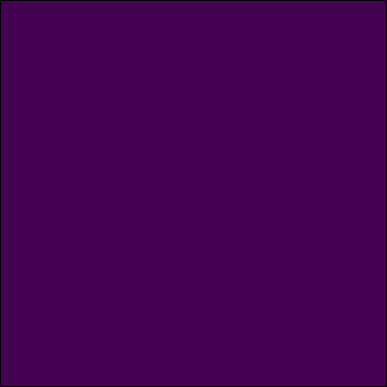

In [67]:
# Save GIFs to Examples folder and display them
from wta2d import save_gif
from IPython.display import Image, display

save_gif(xs_open, aa_open, "center_blob_open.gif", cmap="viridis", border=1, nframe=80)
save_gif(xs_toroidal, aa_toroidal, "center_blob_toroidal.gif", cmap="viridis", border=1, nframe=80)

print("Saved Examples/center_blob_open.gif and Examples/center_blob_toroidal.gif")
display(Image(filename="Examples/center_blob_open.gif"))
display(Image(filename="Examples/center_blob_toroidal.gif"))